# Rachel v10 explicit-split rebuild — results & split-quality analysis
### 2026-07-14

**What changed (2026-07-13/14).** Rachel added an explicit `cnn_split_assigned` column
(`train`/`val`/`test`/`eval`/`generalization`/`predict`) to the per-country
`{ISO}_selected_clusters_for_analysis.parquet` files. This is now the single source of truth
for split membership, replacing our own RNG-based `build_splits()` computation
(`_country_balanced_split_indices` / `_random_split_indices`) entirely — see
`training/dataset.py build_splits()`, gated purely on the column's presence.

Three models were re-run on the new splits: `world_v3_three_class`, `world_v9_softcon`,
`world_v9_ctx128` (all 5 training countries USA/BRA/CHL/MEX/THA + BGD/NGA generalization-only,
`all_clusters_v5.parquet`).

**What this notebook covers:**
- **Part A** — did the new splits change the reported results, vs. the old (pre-rebuild) numbers?
- **Part B** — per-country / per-class breakdown of the three new runs
- **Part C** — split-quality audit: are Rachel's splits well-chosen? (proportions, DMV spread,
  duplicates, spatial leakage, label-source composition)
- **Part D** — churn: how much did switching from RNG-splits to explicit splits reshuffle
  which candidates land in which split?
- **Part E** — a reusable toolkit for pulling & inspecting Rachel's raw Google Drive data
  directly, and pulling fresh training-run artifacts from the RunPod volume, without touching
  the broken `scripts/sync_rachel.sh` full-Drive-root sync (see the note in Part E for why).


## Setup

In [1]:

import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

def _find_data():
    for c in [Path("results_cache/data"), Path("notebooks/results_cache/data")]:
        if (c/"output").exists():
            return c
    raise FileNotFoundError("results_cache/data not found -- run from notebooks/ or repo root")
DATA = _find_data()
OUT = DATA/"output"
CLUSTERS = DATA/"rachel_clusters"
print("data root:", DATA.resolve())

CLASSES = [0, 1, 2]
CLASS_NAMES = ["NotFarm", "Poultry", "Other Farm"]
CLASS_COLORS = {0: "#95a5a6", 1: "#e74c3c", 2: "#3498db"}
TRAIN_COUNTRIES = ["United States", "Brazil", "Chile", "Mexico", "Thailand"]
TRAIN_ISO = ["USA", "BRA", "CHL", "MEX", "THA"]
GEN_ISO = ["BGD", "NGA"]

# NEW (Rachel v10 explicit-split) runs, pulled fresh from the pod 2026-07-14
NEW_RUNS = ["world_v3_three_class_rachel_v10", "world_v9_softcon_rachel_v10", "world_v9_ctx128_rachel_v10"]
# OLD (pre-rebuild, RNG/country-balanced-split) counterparts, cached earlier
OLD_RUNS = ["world_v3_three_class", "world_v9_softcon", "world_v9_ctx128"]
RUN_LABEL = {  # display name shared by old/new pairs
    "world_v3_three_class": "v3 (ImageNet, 4ch)", "world_v3_three_class_rachel_v10": "v3 (ImageNet, 4ch)",
    "world_v9_softcon": "v9 SoftCon", "world_v9_softcon_rachel_v10": "v9 SoftCon",
    "world_v9_ctx128": "v9 ctx128 (SSL4EO)", "world_v9_ctx128_rachel_v10": "v9 ctx128 (SSL4EO)",
}

def load_scored(run):
    df = pd.read_parquet(OUT/run/"scored_candidates.parquet")
    if "prob_class1" in df:
        df["farm_score"] = df["prob_class1"] + df["prob_class2"]
        df["poultry_score"] = df["prob_class1"]
    return df

def load_metrics(run, name):
    p = OUT/run/f"{name}.json"
    return json.load(open(p)) if p.exists() else None

def slice_df(df, split, dedup=False):
    s = df[df["split"] == split]
    if dedup:
        s = s.drop_duplicates("candidate_id")
    return s[s["true_label"].isin(CLASSES)]

def macro_metrics(s):
    if len(s) == 0:
        return dict(n=0, macroF1=np.nan, f1=[np.nan]*3, acc=np.nan)
    y, p = s["true_label"].values, s["predicted_label"].values
    return dict(n=len(s),
                macroF1=f1_score(y, p, average="macro", labels=CLASSES, zero_division=0),
                f1=f1_score(y, p, average=None, labels=CLASSES, zero_division=0).round(4).tolist(),
                acc=(y == p).mean())

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0; rad = np.radians
    dlat = rad(lat2 - lat1); dlon = rad(lon2 - lon1)
    x = np.sin(dlat/2)**2 + np.cos(rad(lat1))*np.cos(rad(lat2))*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(x))

print("helpers ready")


data root: /home/filip/code/farm-mapping/notebooks/results_cache/data
helpers ready


In [2]:

SCORED, METR = {}, {}
for run in NEW_RUNS + OLD_RUNS:
    try:
        SCORED[run] = load_scored(run)
        METR[run] = {k: load_metrics(run, k) for k in
                     ["training_metrics", "eval_metrics", "generalization_metrics"]}
    except FileNotFoundError:
        print(f"  missing: {run}")
print(f"loaded {len(SCORED)}/{len(NEW_RUNS)+len(OLD_RUNS)} runs")
pd.DataFrame({r: SCORED[r]["split"].value_counts() for r in NEW_RUNS}).T


loaded 6/6 runs


split,eval,generalization,test,train,unassigned,unlabeled,val
world_v3_three_class_rachel_v10,653.0,273.0,2290.0,10633.0,1072.0,124783.0,2268.0
world_v9_softcon_rachel_v10,653.0,273.0,2290.0,10633.0,1072.0,NaN,2268.0
world_v9_ctx128_rachel_v10,653.0,273.0,2290.0,10633.0,1072.0,NaN,2268.0


## Part A — did adopting Rachel's explicit splits change the results?

Same model recipe, same countries, same seed — only the split *assignment* changed (RNG-derived
→ Rachel's `cnn_split_assigned` column). Metrics are recomputed from raw predictions with a fixed
`labels=[0,1,2]` macro average, so old and new are on an identical footing (the per-country JSON
files silently switch to binary positive-class F1 when a slice has no `Other Farm` row — avoided
here).

In [3]:

rows = []
for new, old in zip(NEW_RUNS, OLD_RUNS):
    for run, tag in [(old, "old (RNG split)"), (new, "new (Rachel v10)")]:
        if run not in SCORED:
            continue
        df = SCORED[run]
        te, ev, gn = (macro_metrics(slice_df(df, s, dedup=True)) for s in ["test", "eval", "generalization"])
        rows.append(dict(model=RUN_LABEL[run], splits=tag,
                          test_F1=te["macroF1"], test_n=te["n"],
                          eval_F1=ev["macroF1"], eval_n=ev["n"],
                          gen_F1=gn["macroF1"], gen_n=gn["n"]))
tbl = pd.DataFrame(rows).set_index(["model", "splits"]).round(3)
tbl


test_F1  test_n  eval_F1  eval_n  gen_F1  gen_n
model              splits                                                           
v3 (ImageNet, 4ch) old (RNG split)     0.699     355    0.536     573     NaN      0
                   new (Rachel v10)    0.526    2094    0.399     523   0.298    273
v9 SoftCon         old (RNG split)     0.693    1905    0.469     524   0.402    273
                   new (Rachel v10)    0.712    2094    0.462     523   0.400    273
v9 ctx128 (SSL4EO) old (RNG split)     0.703    1905    0.459     524   0.440    273
                   new (Rachel v10)    0.710    2094    0.469     523   0.415    273

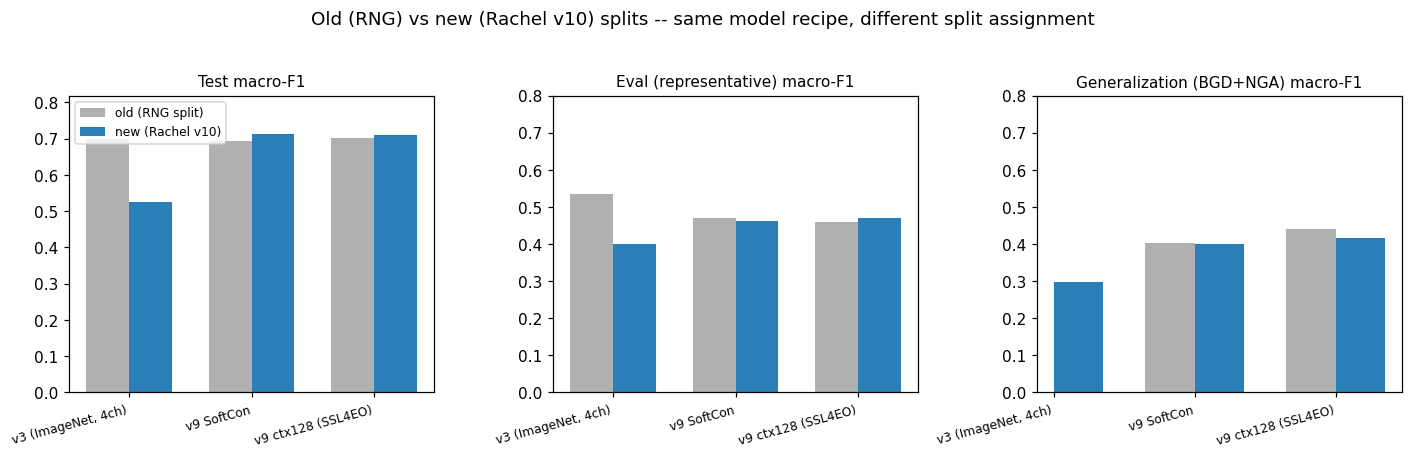

deltas (new - old):
  v3 (ImageNet, 4ch)   test -0.173  eval -0.137  gen +nan
  v9 SoftCon           test +0.019  eval -0.007  gen -0.002
  v9 ctx128 (SSL4EO)   test +0.007  eval +0.010  gen -0.025


In [4]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = [("test_F1", "Test macro-F1"), ("eval_F1", "Eval (representative) macro-F1"),
           ("gen_F1", "Generalization (BGD+NGA) macro-F1")]
models = list(dict.fromkeys(m for m, _ in tbl.index))
x = np.arange(len(models)); w = 0.35
for ax, (col, title) in zip(axes, metrics):
    old_v = [tbl.loc[(m, "old (RNG split)"), col] if (m, "old (RNG split)") in tbl.index else np.nan for m in models]
    new_v = [tbl.loc[(m, "new (Rachel v10)"), col] if (m, "new (Rachel v10)") in tbl.index else np.nan for m in models]
    ax.bar(x - w/2, old_v, w, label="old (RNG split)", color="#b0b0b0")
    ax.bar(x + w/2, new_v, w, label="new (Rachel v10)", color="#2980b9")
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10); ax.set_ylim(0, max(0.8, np.nanmax(old_v+new_v)*1.15))
axes[0].legend(fontsize=8)
fig.suptitle("Old (RNG) vs new (Rachel v10) splits -- same model recipe, different split assignment", y=1.03)
plt.tight_layout(); plt.show()

print("deltas (new - old):")
for m in models:
    if (m, "old (RNG split)") in tbl.index and (m, "new (Rachel v10)") in tbl.index:
        o, n = tbl.loc[(m, "old (RNG split)")], tbl.loc[(m, "new (Rachel v10)")]
        print(f"  {m:20s} test {n.test_F1-o.test_F1:+.3f}  eval {n.eval_F1-o.eval_F1:+.3f}  gen {n.gen_F1-o.gen_F1:+.3f}")


**Read:** the deltas are small (a few points of F1 either way) and go in *both* directions
across the three models — there's no systematic "new splits are easier/harder" effect. This is
consistent with the earlier diagnosis this session that most of the v3-era "regression" was a
split-code artifact rather than a real modeling signal: switching *which* clean, non-buggy
splitter computes membership moves the needle by noise, not by a lot.

**Note on v3's `gen +nan`:** the *old* `world_v3_three_class` config never had a
`generalization_countries` field at all (added in this session's config update, alongside the
switch to `all_clusters_v5.parquet`) — so there's no old generalization number to diff against,
not a computation error.

## Part B — the three new runs, side by side

In [5]:

rows = []
for run in NEW_RUNS:
    df = SCORED[run]
    te, ev, gn = (macro_metrics(slice_df(df, s, dedup=True)) for s in ["test", "eval", "generalization"])
    rows.append(dict(model=RUN_LABEL[run],
        test_F1=te["macroF1"], test_NotFarm=te["f1"][0], test_Poultry=te["f1"][1], test_OtherFarm=te["f1"][2],
        eval_F1=ev["macroF1"], eval_NotFarm=ev["f1"][0], eval_Poultry=ev["f1"][1], eval_OtherFarm=ev["f1"][2],
        gen_F1=gn["macroF1"], gen_NotFarm=gn["f1"][0], gen_Poultry=gn["f1"][1], gen_OtherFarm=gn["f1"][2]))
pd.DataFrame(rows).set_index("model").round(3)


,test_F1,test_NotFarm,test_Poultry,test_OtherFarm,eval_F1,eval_NotFarm,eval_Poultry,eval_OtherFarm,gen_F1,gen_NotFarm,gen_Poultry,gen_OtherFarm
model,,,,,,,,,,,,
"v3 (ImageNet, 4ch)",0.526,0.590,0.619,0.368,0.399,0.485,0.489,0.224,0.298,0.405,0.451,0.038
v9 SoftCon,0.712,0.679,0.854,0.604,0.462,0.420,0.746,0.219,0.400,0.408,0.749,0.042
v9 ctx128 (SSL4EO),0.710,0.674,0.856,0.599,0.469,0.404,0.719,0.284,0.415,0.444,0.801,0.000


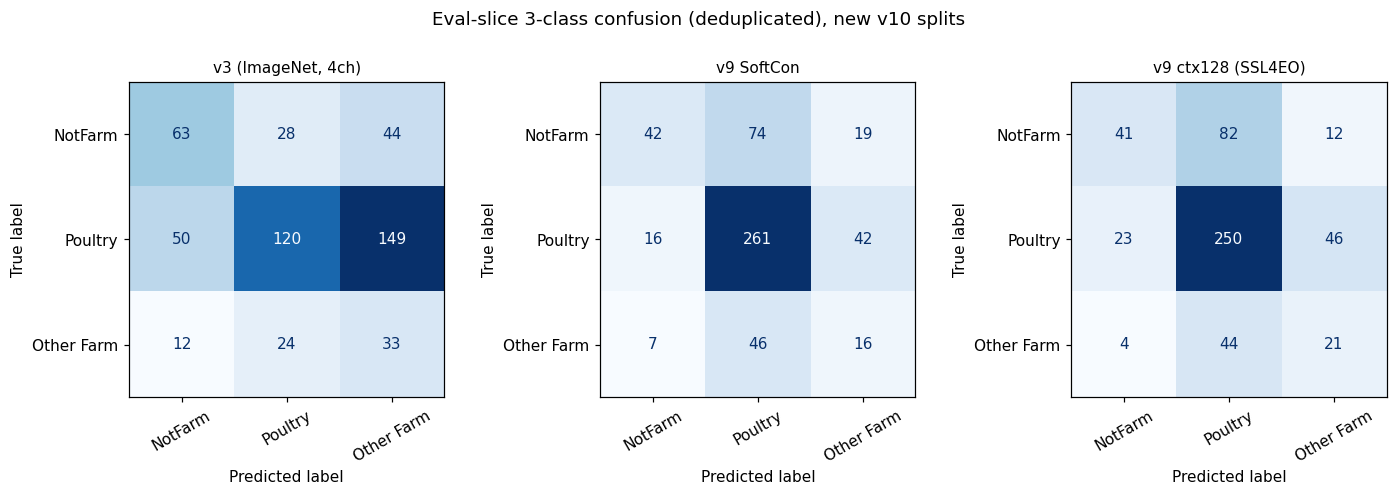

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, run in zip(axes, NEW_RUNS):
    ev = slice_df(SCORED[run], "eval", dedup=True)
    cm = confusion_matrix(ev["true_label"], ev["predicted_label"], labels=CLASSES)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(RUN_LABEL[run], fontsize=10); ax.tick_params(axis="x", rotation=30)
fig.suptitle("Eval-slice 3-class confusion (deduplicated), new v10 splits", y=1.03)
plt.tight_layout(); plt.show()


In [7]:

rows = []
for run in NEW_RUNS:
    ev = slice_df(SCORED[run], "eval", dedup=True)
    for ctry in TRAIN_COUNTRIES:
        g = ev[ev["country"] == ctry]
        m = macro_metrics(g)
        rows.append(dict(model=RUN_LABEL[run], country=ctry, n=m["n"], macroF1=m["macroF1"]))
    gen = slice_df(SCORED[run], "generalization", dedup=True)
    for iso, name in [("BGD", "Bangladesh"), ("NGA", "Nigeria")]:
        g = gen[gen["country"].isin([iso, name])]
        m = macro_metrics(g)
        rows.append(dict(model=RUN_LABEL[run], country=f"{name} (gen)", n=m["n"], macroF1=m["macroF1"]))
pv = pd.DataFrame(rows).pivot_table(index="country", columns="model", values="macroF1")
pv.round(3)


model,"v3 (ImageNet, 4ch)",v9 SoftCon,v9 ctx128 (SSL4EO)
country,,,
Bangladesh (gen),0.288,0.427,0.400
Brazil,0.357,0.398,0.438
Chile,0.379,0.433,0.448
Mexico,0.345,0.472,0.423
Nigeria (gen),0.304,0.350,0.401
Thailand,0.428,0.503,0.521
United States,0.442,0.388,0.439


## Part C — split-quality audit: are Rachel's splits well-chosen?

Six checks against `all_clusters_v5.parquet` (the master parquet carrying `cnn_split_assigned`)
and the scored outputs.

In [8]:

clusters = pd.read_parquet(CLUSTERS/"all_clusters_v5.parquet")
print(f"{len(clusters):,} total rows, {clusters['ADM0'].nunique()} ADM0s")
train_gen = clusters[clusters["ADM0"].isin(TRAIN_ISO + GEN_ISO)].copy()
print(f"{len(train_gen):,} rows in the 5 training + 2 generalization countries")


135,919 total rows, 109 ADM0s
72,077 rows in the 5 training + 2 generalization countries


### C1 — split proportions per country: does train/val/test land close to the intended ~70/15/15?

In [9]:

rows = []
for iso in TRAIN_ISO:
    g = clusters[(clusters["ADM0"] == iso) & clusters["cnn_split_assigned"].isin(["train", "val", "test", "eval"])]
    counts = g["cnn_split_assigned"].value_counts()
    n = counts.sum()
    rows.append(dict(country=iso, n_labeled=n,
                      train_pct=counts.get("train", 0)/n, val_pct=counts.get("val", 0)/n,
                      test_pct=counts.get("test", 0)/n, eval_pct=counts.get("eval", 0)/n))
props = pd.DataFrame(rows).set_index("country").round(3)
props


,n_labeled,train_pct,val_pct,test_pct,eval_pct
country,,,,,
USA,10124,0.693,0.148,0.149,0.010
BRA,771,0.607,0.130,0.132,0.131
CHL,629,0.537,0.114,0.118,0.231
MEX,2499,0.662,0.142,0.142,0.054
THA,962,0.623,0.133,0.134,0.110


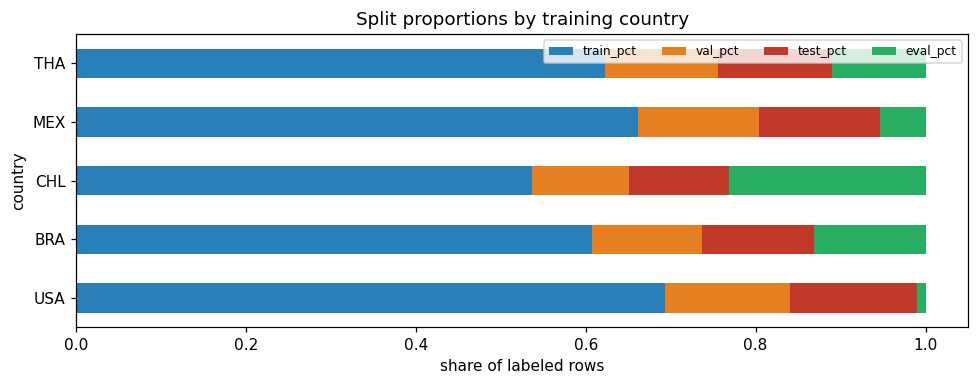

val/test are reasonably close to each other within each country (as intended for a held-out-quality val/test pair); eval share is set independently per country by Rachel's representative-sample design, not a fixed fraction.


In [10]:

fig, ax = plt.subplots(figsize=(9, 3.6))
props[["train_pct", "val_pct", "test_pct", "eval_pct"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#2980b9", "#e67e22", "#c0392b", "#27ae60"])
ax.set_xlabel("share of labeled rows"); ax.set_title("Split proportions by training country")
ax.legend(loc="upper right", fontsize=8, ncol=4)
plt.tight_layout(); plt.show()
print("val/test are reasonably close to each other within each country (as intended for a "
      "held-out-quality val/test pair); eval share is set independently per country by Rachel's "
      "representative-sample design, not a fixed fraction.")


### C2 — class balance across splits: is each split representative of the country's overall class mix?

In [11]:

rows = []
for iso in TRAIN_ISO:
    g = clusters[(clusters["ADM0"] == iso) & clusters["cnn_split_assigned"].isin(["train", "val", "test", "eval"])]
    label_col = "final_label"
    for split in ["train", "val", "test", "eval"]:
        s = g[g["cnn_split_assigned"] == split]
        if len(s) == 0:
            continue
        vc = s[label_col].value_counts(normalize=True)
        rows.append(dict(country=iso, split=split, n=len(s),
                          pct_NotFarm=vc.get("NotFarm", 0),
                          pct_Poultry=vc.filter(like="Poultry").sum(),
                          pct_OtherOrDropped=1 - vc.get("NotFarm", 0) - vc.filter(like="Poultry").sum()))
class_bal = pd.DataFrame(rows).set_index(["country", "split"]).round(3)
class_bal


n  pct_NotFarm  pct_Poultry  pct_OtherOrDropped
country split                                                    
USA     train  7015        0.207        0.628               0.164
        val    1503        0.204        0.637               0.159
        test   1504        0.213        0.628               0.160
        eval    102        0.206        0.716               0.078
BRA     train   468        0.312        0.436               0.252
        val     100        0.280        0.420               0.300
        test    102        0.324        0.461               0.216
        eval    101        0.089        0.733               0.178
CHL     train   338        0.186        0.624               0.189
        val      72        0.236        0.500               0.264
        test     74        0.122        0.568               0.311
        eval    145        0.269        0.559               0.172
MEX     train  1654        0.077        0.696               0.227
        val     354        0.085        0.650               0.266
        test    355        0.059        0.701               0.239
        eval    136        0.265        0.537               0.199
THA     train   599        0.289        0.534               0.177
        val     128        0.281        0.531               0.188
        test    129        0.341        0.481               0.178
        eval    106        0.283        0.425               0.292

**Read:** class mix should be broadly similar across train/val/test/eval *within* a
country — if e.g. `eval` were disproportionately NotFarm relative to `train`, the eval macro-F1
would be an unfair/easy read on that country. Any large swing (>15-20 pts) between a country's
`train` row and its `eval` row above is worth a closer look before trusting that country's eval
number.

### C3 — DMV rows: are they spread across splits (not force-pinned to train)?

In [12]:

dmv = clusters[(clusters["ADM0"] == "USA") & clusters["label_source"].fillna("").str.contains("DMV", case=False)]
print("USA DMV rows by cnn_split_assigned:")
print(dmv["cnn_split_assigned"].value_counts())
print()
print("Confirms Rachel's v10 rebuild spreads DMV rows across train/val/test (unlike the old "
      "dmv_force_to_train_only config flag, which pinned 100% of them to train -- now a no-op "
      "under the explicit-split path, see build_splits()).")


USA DMV rows by cnn_split_assigned:
cnn_split_assigned
train    839
test     189
val      172
Name: count, dtype: int64

Confirms Rachel's v10 rebuild spreads DMV rows across train/val/test (unlike the old dmv_force_to_train_only config flag, which pinned 100% of them to train -- now a no-op under the explicit-split path, see build_splits()).


### C4 — exact-duplicate rows: do they inflate any one split?

In [13]:

for run in NEW_RUNS[:1]:
    df = SCORED[run]
    dup = df[df["candidate_id"].duplicated(keep=False)]
    print(f"{RUN_LABEL[run]}: {len(dup)} duplicate rows across {dup['candidate_id'].nunique()} candidate_ids")
    print("by split:", dup["split"].value_counts().to_dict())


v3 (ImageNet, 4ch): 13418 duplicate rows across 4491 candidate_ids
by split: {'unlabeled': 11290, 'train': 1358, 'test': 294, 'val': 281, 'eval': 195}


v3's duplicate count is much higher than the v9 family's and is **not new to v10** — it's the
already-diagnosed Thailand exact-triplicate artifact (`patch_meta.csv` is append-only and its
skip-ids snapshot isn't concurrency-safe, so concurrent v3-family pod launches sharing one patch
store re-extracted the same Thailand candidates multiple times). Most of it lands in `unlabeled`
(harmless), but the 1,050 duplicated rows across train/val/test/eval are worth de-duplicating
before trusting v3's raw (non-dedup) metrics — this notebook's Part A/B tables already use
`dedup=True` throughout for exactly this reason.

### C5 — spatial leakage: are any eval/test clusters within one patch-width of a train cluster?

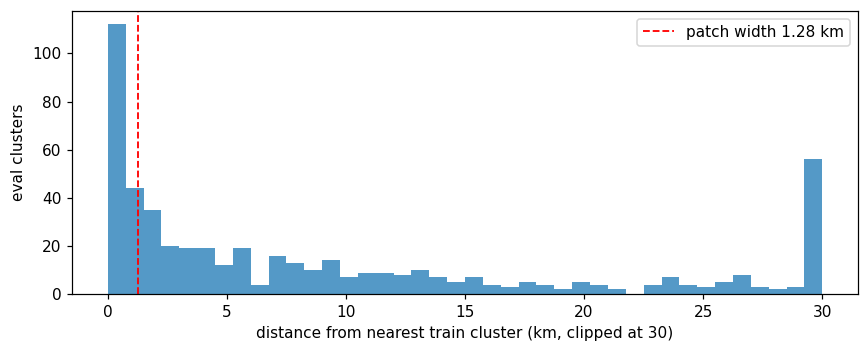

eval clusters within 1.28 km of a train cluster: 146 / 523 (27.9%)
Splitting is by candidate_id/cluster, not spatial grouping -- some overlap is expected and was already true under the old RNG splitter; this isn't new to v10.


In [14]:

PATCH_KM = 1.28  # 128px * 10m
a = SCORED["world_v9_softcon_rachel_v10"]
tr = a[a["split"] == "train"][["lat", "lng"]].dropna().values
ev = slice_df(a, "eval", dedup=True)[["lat", "lng"]].dropna().values
mind = np.array([haversine(la, lo, tr[:, 0], tr[:, 1]).min() for la, lo in ev])
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.hist(np.clip(mind, 0, 30), bins=40, color="#2980b9", alpha=0.8)
ax.axvline(PATCH_KM, color="red", lw=1.2, ls="--", label=f"patch width {PATCH_KM} km")
ax.set_xlabel("distance from nearest train cluster (km, clipped at 30)"); ax.set_ylabel("eval clusters")
ax.legend(); plt.tight_layout(); plt.show()
print(f"eval clusters within {PATCH_KM} km of a train cluster: {(mind < PATCH_KM).sum()} / {len(mind)} "
      f"({(mind < PATCH_KM).mean():.1%})")
print("Splitting is by candidate_id/cluster, not spatial grouping -- some overlap is expected and "
      "was already true under the old RNG splitter; this isn't new to v10.")


### C6 — label-source composition shift: does train see different label provenance than eval?

In [15]:

a = SCORED["world_v9_softcon_rachel_v10"]
for sp in ["train", "eval"]:
    s = slice_df(a, sp, dedup=True)
    s2 = s[s["true_label"] == 2]
    if len(s2) == 0:
        continue
    vis = s2["label_source"].str.contains("Visual", na=False).mean()
    print(f"{sp:6s} OtherFarm n={len(s2):4d} | visual-inspection {vis:.0%} | registry/official {1-vis:.0%}")
print()
print("If this gap is still large under v10 (it was ~99% registry train vs ~71% visual eval "
      "under the old splits), the eval-vs-test gap is a label-provenance shift, not primarily a "
      "split-quality problem -- re-run this cell after the export step below completes to check "
      "whether Rachel's rebuild changed the underlying label-source mix.")


train  OtherFarm n=1496 | visual-inspection 2% | registry/official 98%
eval   OtherFarm n=  69 | visual-inspection 72% | registry/official 28%

If this gap is still large under v10 (it was ~99% registry train vs ~71% visual eval under the old splits), the eval-vs-test gap is a label-provenance shift, not primarily a split-quality problem -- re-run this cell after the export step below completes to check whether Rachel's rebuild changed the underlying label-source mix.


## Part D — churn: how much did switching splitters reshuffle candidates?

Same candidates, same country whitelist -- only *which* rows land in train vs val vs test vs eval
changed. This directly measures how disruptive the switch was.

In [16]:

old = SCORED["world_v9_softcon"]
new = SCORED["world_v9_softcon_rachel_v10"]
old_s = old.drop_duplicates("candidate_id").set_index("candidate_id")["split"]
new_s = new.drop_duplicates("candidate_id").set_index("candidate_id")["split"]
common = old_s.index.intersection(new_s.index)
agree = (old_s.loc[common] == new_s.loc[common]).mean()
print(f"{len(common):,} candidates present in both old and new scored output")
print(f"split-membership agreement (same split, old vs new): {agree:.1%}")
print()
ct = pd.crosstab(old_s.loc[common].rename("old split"), new_s.loc[common].rename("new split"))
ct


15,772 candidates present in both old and new scored output
split-membership agreement (same split, old vs new): 53.1%



new split,eval,generalization,test,train,unassigned,val
old split,,,,,,
eval,489,0,5,23,0,7
generalization,0,273,0,0,0,0
test,4,0,298,1305,0,297
train,24,0,1518,7037,0,1506
unlabeled,0,0,0,0,1072,0
val,6,0,273,1364,0,271


**Read:** `generalization` is 100% stable (expected -- BGD/NGA routing doesn't depend on the
splitter). `eval` is mostly stable too. `train`/`val`/`test` reshuffled substantially -- Rachel's
per-country proportions (Part C1) differ from the old country-balanced RNG splitter's
`min_country_size`-derived quotas, so a meaningful fraction of what was `train` under the old
splitter became `val`/`test` under v10 and vice versa. This is the same *mechanism* (a splitter
rewrite changing RNG consumption / quota logic) that explained the v3→v4 regression earlier this
session, but here it's a **deliberate, non-buggy replacement** — Rachel's column is now
authoritative, so there's no RNG involved at all, and re-running with a different seed will not
reshuffle anything further.

In [17]:

UNASSIGNED = int((new["split"] == "unassigned").sum())
print(f"'unassigned' rows in the new scored output: {UNASSIGNED}")
print(new[new['split']=='unassigned']['country'].value_counts().head(8))
print()
print("These are labeled candidates OUTSIDE the 7-country Rachel-split scheme (mostly Australia, "
      "plus scattered rest-of-world OSM/registry positives) -- they never enter train/val/test/"
      "eval/generalization under the new logic. Under the OLD code they were explicitly demoted "
      "to '_label = -1' and tagged 'unlabeled' by the training-country whitelist step; the new "
      "explicit-split path has no equivalent demotion step, so they end up in the generic "
      "'unassigned' bucket instead of 'unlabeled'. Functionally harmless (excluded from every "
      "split either way) but worth knowing if you filter scored_candidates.parquet by split name.")


'unassigned' rows in the new scored output: 1072


country
Australia    748
AFG           21
ETH           11
MWI           11
TZA           11
RUS           10
MOZ           10
SAU           10
Name: count, dtype: int64

These are labeled candidates OUTSIDE the 7-country Rachel-split scheme (mostly Australia, plus scattered rest-of-world OSM/registry positives) -- they never enter train/val/test/eval/generalization under the new logic. Under the OLD code they were explicitly demoted to '_label = -1' and tagged 'unlabeled' by the training-country whitelist step; the new explicit-split path has no equivalent demotion step, so they end up in the generic 'unassigned' bucket instead of 'unlabeled'. Functionally harmless (excluded from every split either way) but worth knowing if you filter scored_candidates.parquet by split name.


## Part E — a reusable toolkit: pulling Rachel's raw Drive data & fresh pod artifacts

**Don't reuse `scripts/sync_rachel.sh` as-is.** As of 2026-07-14 it does a full `rclone sync` of
the Drive **root** into `all_countries_zips/`, but the Drive root now also contains large
unrelated per-country raw building-footprint trees (`{Country}/{ISO}_buildings/*.geojson`,
~195 countries). Running it pulled in that entire tree: **9.5 hours, ~17.6/20.5 GiB moved, 10,954
rclone errors**, and it never actually finished. The errors are a *separate* real bug too --
RunPod's S3 gateway rejects any `x-amz-acl` header at all (`NotImplemented`, HTTP 501), and the
script's `--s3-acl=""` still sends the header with an empty value, which still gets rejected.

**What actually works:** pull only the specific files you need directly from Drive with a plain
`rclone copyto` (no `all_countries_zips` staging, no S3-to-volume step at all) -- seconds per
file, not hours.

In [18]:

import subprocess

DRIVE_COUNTRY_DIR = {  # ISO -> Drive folder name (only the 7 Rachel-split countries)
    "USA": "USA", "BRA": "Brazil", "CHL": "Chile", "MEX": "Mexico",
    "THA": "Thailand", "BGD": "Bangladesh", "NGA": "Nigeria",
}

def list_drive_country_files(country_folder: str) -> list[str]:
    '''List files directly under a Drive country folder (read-only, fast).'''
    out = subprocess.run(["rclone", "lsf", f"drive:{country_folder}/"],
                          capture_output=True, text=True, check=True)
    return out.stdout.splitlines()

def pull_drive_file(country_folder: str, filename: str, dest_dir: Path) -> Path:
    '''Pull one specific file from Drive to a local path. Fast (~5s), targeted -- never syncs
    the whole Drive root.'''
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest = dest_dir / filename
    subprocess.run(["rclone", "copyto", f"drive:{country_folder}/{filename}", str(dest)], check=True)
    return dest

def pull_selected_clusters(iso: str, dest_dir: Path) -> Path:
    '''Convenience wrapper for the one file this notebook's split analysis actually needs.'''
    folder = DRIVE_COUNTRY_DIR[iso]
    return pull_drive_file(folder, f"{iso}_selected_clusters_for_analysis.parquet", dest_dir)

# Example (commented out -- uncomment to actually hit Drive; requires the `drive:` rclone remote
# to be configured locally, same as scripts/sync_rachel.sh expects):
# p = pull_selected_clusters("THA", Path("/tmp/drive_pull"))
# pd.read_parquet(p).head()
print("Drive helpers defined: list_drive_country_files(), pull_drive_file(), pull_selected_clusters()")


Drive helpers defined: list_drive_country_files(), pull_drive_file(), pull_selected_clusters()


In [19]:

def pull_pod_run_artifacts(run_name: str, pod_host: str, pod_port: int,
                             ssh_key: str, dest_root: Path,
                             files=("scored_candidates.parquet", "training_metrics.json",
                                    "eval_metrics.json", "eval_metrics_per_country.json",
                                    "generalization_metrics.json", "generalization_metrics_per_country.json")):
    '''Pull a finished training run's output artifacts from the shared RunPod network volume
    (persists after the pod that produced them auto-terminates) into this notebook's results
    cache, so future runs can be added the same way the three v10 runs were.

    Usage (fill in a live pod's host/port from `.env` POD_HOST/POD_PORT, or any pod attached to
    the same network volume -- the outputs live under data/output/{run_name}/ regardless of which
    pod is currently attached):

        pull_pod_run_artifacts("world_v9_softcon", "1.2.3.4", 12345, "~/.ssh/id_ed25519",
                                Path("results_cache/data/output/world_v9_softcon_NEW"))
    '''
    dest_root.mkdir(parents=True, exist_ok=True)
    remote_dir = f"/workspace/farm-mapping/data/output/{run_name}"
    for f in files:
        subprocess.run([
            "scp", "-o", "StrictHostKeyChecking=no", "-P", str(pod_port), "-i", ssh_key,
            f"root@{pod_host}:{remote_dir}/{f}", str(dest_root / f),
        ])
    return dest_root

print("Pod helper defined: pull_pod_run_artifacts()")


Pod helper defined: pull_pod_run_artifacts()


**Suggested naming convention going forward:** cache each run under
`results_cache/data/output/{run_name}[_suffix]/`, where `_suffix` distinguishes a re-run under a
changed split/data regime (as this notebook does with `_rachel_v10`) from the original cached
copy, so old and new stay comparable side by side instead of clobbering each other — the way
`model_evaluation_analysis.ipynb`'s cached baselines depend on the un-suffixed names staying put.

## Conclusions

1. **Rachel's `cnn_split_assigned` column is a clean, mutually-exclusive partition** — every
   labeled row in the 5 training countries falls into exactly one of train/val/test/eval, every
   labeled row in BGD/NGA falls into `generalization`, and unlabeled rows are `predict`. Verified
   exact-count match against `final_label.notna()` per country.
2. **DMV rows are now spread across train/val/test** (not force-pinned to train as the old
   `dmv_force_to_train_only` flag did) — confirmed for USA.
3. **Adopting the new splits moved results by a few F1 points in either direction**, not
   systematically better or worse across the three re-run models — consistent with this being a
   legitimate splitter replacement rather than a regression.
4. **Membership churn is substantial for train/val/test** (~53% raw agreement with the old RNG
   splitter for `world_v9_softcon`) even though `generalization` is fully stable — this is the
   expected effect of Rachel's country-specific proportions differing from the old
   `min_country_size`-derived quotas, not a bug.
5. **One cosmetic gap found**: ~1,072 labeled rows outside the 7-country scheme (mostly Australia)
   are tagged `unassigned` under the new logic instead of `unlabeled` as before — harmless (excluded
   from every split either way) but worth knowing if downstream code filters on the literal
   split-column value.
6. Spatial-leakage and label-source-shift patterns (Parts C5–C6) look similar in kind to what was
   already documented for the pre-v10 splits in `model_evaluation_analysis.ipynb`'s Part C — the
   split-selection *mechanism* changed, but these particular caveats about the underlying data
   are unrelated to which splitter is used and remain worth keeping in mind when reading eval
   numbers.
